# Fulfillment Control Tower

## Dashboard Preparation and Business Recommendations

In [1]:
from pathlib import Path
import pandas as pd

PROCESSED_DATA_DIR = Path("../data/processed")

orders_analysis = pd.read_csv(
    PROCESSED_DATA_DIR / "orders_analysis.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

seller_performance = pd.read_csv(
    PROCESSED_DATA_DIR / "seller_performance.csv"
)

category_summary = pd.read_csv(
    PROCESSED_DATA_DIR / "category_summary.csv"
)

In [2]:
print(orders_analysis.shape)
print(seller_performance.shape)
print(category_summary.shape)

(99441, 21)
(3095, 4)
(51, 12)


In [3]:
dashboard_kpis = pd.DataFrame({
    "total_orders": [
        orders_analysis["order_id"].nunique()
    ],
    "delivered_orders": [
        orders_analysis["order_delivered_customer_date"].notna().sum()
    ],
    "late_delivery_rate": [
        orders_analysis.loc[
            orders_analysis["order_delivered_customer_date"].notna(),
            "is_late"
        ].mean()
    ],
    "average_review_score": [
        orders_analysis["review_score"].mean()
    ],
    "median_delivery_days": [
        orders_analysis["delivery_days"].median()
    ],
    "median_handling_days": [
        orders_analysis["handling_days"].median()
    ],
    "median_freight_value": [
        orders_analysis["total_freight_value"].median()
    ],
    "median_freight_ratio": [
        orders_analysis["freight_ratio"].median()
    ]
})

dashboard_kpis

,total_orders,delivered_orders,late_delivery_rate,average_review_score,median_delivery_days,median_handling_days,median_freight_value,median_freight_ratio
0,99441,96476,0.067737,4.086793,10.0,1.0,17.17,0.224374


In [4]:
dashboard_kpis_display = dashboard_kpis.copy()

dashboard_kpis_display["late_delivery_rate"] = (
    dashboard_kpis_display["late_delivery_rate"] * 100
).round(2)

dashboard_kpis_display["median_freight_ratio"] = (
    dashboard_kpis_display["median_freight_ratio"] * 100
).round(2)

dashboard_kpis_display[
    [
        "total_orders",
        "delivered_orders",
        "late_delivery_rate",
        "average_review_score",
        "median_delivery_days",
        "median_handling_days",
        "median_freight_value",
        "median_freight_ratio"
    ]
]

,total_orders,delivered_orders,late_delivery_rate,average_review_score,median_delivery_days,median_handling_days,median_freight_value,median_freight_ratio
0,99441,96476,6.77,4.086793,10.0,1.0,17.17,22.44


In [5]:
dashboard_kpis_display.to_csv(
    PROCESSED_DATA_DIR / "dashboard_kpis.csv",
    index=False
)

In [7]:
monthly_data = orders_analysis.assign(
    purchase_month=orders_analysis[
        "order_purchase_timestamp"
    ].dt.to_period("M").astype(str)
)

monthly_performance = (
    monthly_data.groupby("purchase_month", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        delivered_orders=(
            "order_delivered_customer_date",
            lambda x: x.notna().sum()
        ),
        average_review_score=("review_score", "mean"),
        median_delivery_days=("delivery_days", "median"),
        median_handling_days=("handling_days", "median"),
        median_freight_value=("total_freight_value", "median")
    )
)

In [8]:
monthly_late_rate = (
    monthly_data[
        monthly_data["order_delivered_customer_date"].notna()
    ]
    .groupby("purchase_month", as_index=False)
    .agg(
        late_delivery_rate=("is_late", "mean")
    )
)

monthly_late_rate["late_delivery_rate"] = (
    monthly_late_rate["late_delivery_rate"] * 100
)

In [9]:
monthly_performance = monthly_performance.merge(
    monthly_late_rate,
    on="purchase_month",
    how="left"
)

monthly_performance = monthly_performance[
    [
        "purchase_month",
        "total_orders",
        "delivered_orders",
        "late_delivery_rate",
        "average_review_score",
        "median_delivery_days",
        "median_handling_days",
        "median_freight_value"
    ]
]

monthly_performance.head()

,purchase_month,total_orders,delivered_orders,late_delivery_rate,average_review_score,median_delivery_days,median_handling_days,median_freight_value
0,2016-09,4,1,100.000000,1.000000,54.0,31.5,15.560
1,2016-10,324,270,0.740741,3.561129,17.0,8.0,17.565
2,2016-12,1,1,0.000000,5.000000,4.0,3.0,8.720
3,2017-01,800,750,2.933333,4.062658,10.0,1.0,18.000
4,2017-02,1780,1653,2.964307,4.015837,10.0,1.0,17.190


In [10]:
monthly_performance_reliable = monthly_performance[
    monthly_performance["delivered_orders"] >= 100
].copy()

monthly_performance_reliable

,purchase_month,total_orders,delivered_orders,late_delivery_rate,average_review_score,median_delivery_days,median_handling_days,median_freight_value
1,2016-10,324,270,0.740741,3.561129,17.0,8.0,17.565
3,2017-01,800,750,2.933333,4.062658,10.0,1.0,18.000
4,2017-02,1780,1653,2.964307,4.015837,10.0,1.0,17.190
5,2017-03,2682,2546,4.556167,4.074596,10.0,1.0,16.500
6,2017-04,2404,2303,6.556665,4.046083,12.0,1.0,16.750
7,2017-05,3700,3545,2.990127,4.142117,9.0,1.0,16.460
8,2017-06,3245,3135,3.030303,4.147763,10.0,1.0,16.490
9,2017-07,4026,3872,2.789256,4.175397,10.0,1.0,16.480
10,2017-08,4331,4193,2.909611,4.237436,9.0,1.0,16.520
11,2017-09,4285,4150,4.385542,4.187838,10.0,2.0,16.810


In [11]:
monthly_performance_reliable.to_csv(
    PROCESSED_DATA_DIR / "monthly_performance.csv",
    index=False
)

In [12]:
sorted(path.name for path in PROCESSED_DATA_DIR.iterdir())

['category_summary.csv',
 'dashboard_kpis.csv',
 'monthly_performance.csv',
 'orders_analysis.csv',
 'seller_performance.csv']

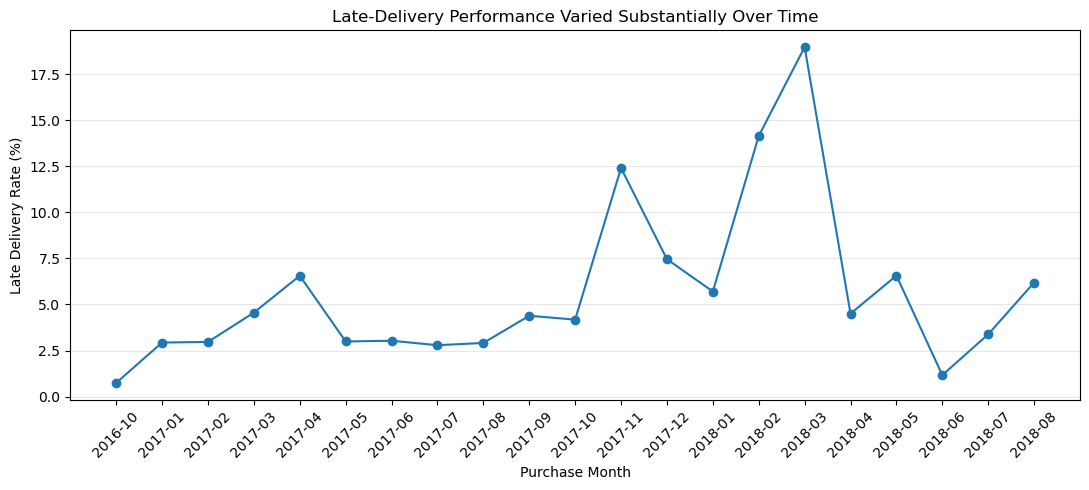

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_performance_reliable["purchase_month"],
    monthly_performance_reliable["late_delivery_rate"],
    marker="o"
)

plt.title("Late-Delivery Performance Varied Substantially Over Time")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Interpretation

Late-delivery performance varied substantially over time. The late rate rose to 12.4% in November 2017 and reached 19.0% in March 2018 before improving sharply in the following months. These spikes suggest that fulfillment risk may be influenced by seasonal demand, operational capacity, carrier performance, or temporary disruptions.

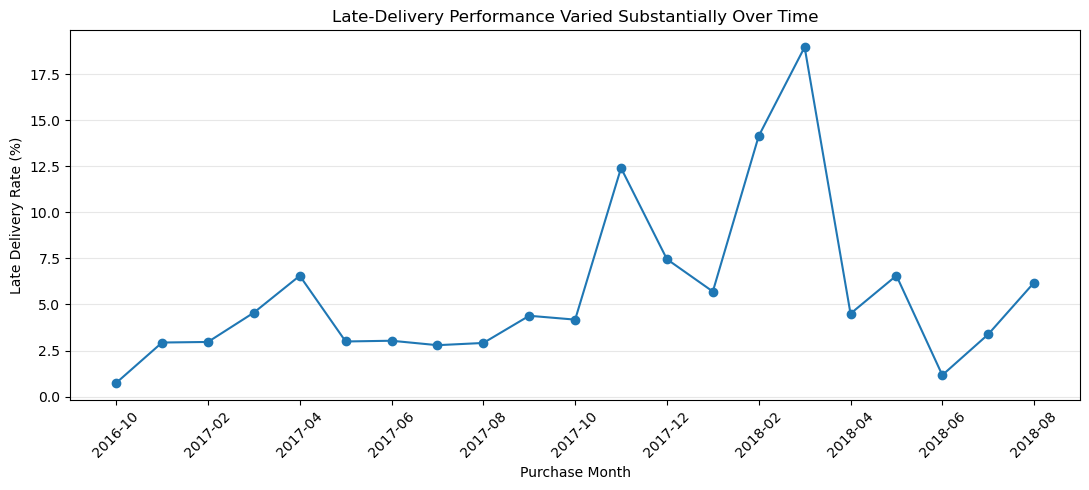

In [14]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_performance_reliable["purchase_month"],
    monthly_performance_reliable["late_delivery_rate"],
    marker="o"
)

plt.title("Late-Delivery Performance Varied Substantially Over Time")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(
    ticks=range(0, len(monthly_performance_reliable), 2),
    labels=monthly_performance_reliable["purchase_month"].iloc[::2],
    rotation=45
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Late-delivery performance varied substantially over time. The late rate rose to 12.4% in November 2017 and peaked at 19.0% in March 2018 before improving sharply. These spikes may reflect seasonal demand, capacity constraints, carrier disruptions, or other temporary operational issues, but the dataset does not establish the exact cause.

## Executive Recommendations

### 1. Create seller handling-time alerts

Seller handling time is one of the clearest actionable warning signals. Orders handled within one day had a 4.6% late rate, while orders taking eight or more days had a 24.3% late rate.

The company should flag orders that remain unshipped after three days and escalate sellers whose median handling time exceeds seven days. Seller monitoring should consider both late rate and order volume so the team focuses on sellers creating the greatest total customer impact.

### 2. Prioritize high-volume categories with concentrated late orders

Bed, bath, and table and health and beauty generated the largest numbers of late orders. These categories should receive targeted operational reviews because even moderate late rates affect hundreds of customers.

The company should examine the main sellers, routes, and handling delays within these categories before applying broad marketplace-wide changes.

### 3. Adjust fulfillment planning for long-distance routes

Orders traveling more than 1,000 km had a 10.2% late rate, compared with 4.5% for routes up to 250 km.

The company should use longer promised delivery windows for high-distance routes, prioritize closer sellers when multiple sellers offer the same product, and identify regions where additional carrier capacity may be needed.

### 4. Reduce freight pressure from heavy and low-value orders

Orders weighing more than 10 kg had a median freight value of 49.97, more than three times the median for orders below 0.5 kg. Electronics and telephony also had high freight costs relative to item value.

The company should review packaging efficiency, minimum-order thresholds, bundling opportunities, and freight-subsidy rules for heavy or low-value products.

### 5. Use monthly monitoring to detect operational spikes early

Late-delivery rates varied substantially over time and peaked at 19.0% in March 2018.

The company should monitor late rate, handling time, seller performance, and review score monthly. Sudden increases should trigger investigation into seller capacity, carrier performance, route disruptions, and seasonal demand.